# Time-Dependent Hartree-Fock (TDHF) for a 1D Two-Electron System

This notebook solves the **time-independent** and **time-dependent** Hartree-Fock
equations for two electrons in a 1D harmonic oscillator trap driven by a laser field,
following the approach of Zanghellini et al.

Both the **General (GHF)** and **Restricted (RHF)** spin representations are implemented.

**Contents**

| § | Topic |
|:--|:------|
| 1 | Imports and global plot style |
| 2 | System parameters |
| 3 | GHF and RHF class definitions |
| 4 | GHF: ground state (TIHF) |
| 5 | GHF: one-body density |
| 6 | GHF: short-time TDHF evolution (laser on) |
| 7 | GHF: Fourier analysis (laser on → off) |
| 8 | RHF: ground state (TIHF) |
| 9 | RHF: one-body density |

## §1 — Environment Setup and Imports

> **First run:** Execute the **Installation** cell below to install `quantum-systems`
> from GitHub, then **restart the kernel**, then run all remaining cells in order.

After installation, the **Imports & Parameters** cell sets up all libraries,
plot style, and physical parameters in one place.

In [1]:
# ── Install quantum-systems (run once, then restart kernel) ──────────────────
# The quantum-systems package by Øyvind Schoyen is NOT on PyPI.
# It must be installed directly from GitHub.
# Documentation: https://schoyen.github.io/quantum-systems/
#
# Run this cell once, then restart the kernel before continuing.

import subprocess, sys

def pip_install(pkg, label=None):
    label = label or pkg
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet', pkg],
        capture_output=True, text=True)
    if result.returncode == 0:
        print(f'  ✓ {label} installed (or already up to date)')
    else:
        print(f'  ✗ {label} FAILED:\n{result.stderr}')

# quantum-systems — install from GitHub (not on PyPI)
pip_install(
    'git+https://github.com/Schoyen/quantum-systems.git',
    label='quantum-systems (Schoyen/quantum-systems)'
)

# Standard scientific stack (likely already installed)
for pkg in ['numpy', 'scipy', 'matplotlib']:
    pip_install(pkg)

print('\nDone. Restart the kernel, then run the next cell.')


  ✓ quantum-systems (Schoyen/quantum-systems) installed (or already up to date)
  ✓ numpy installed (or already up to date)
  ✓ scipy installed (or already up to date)
  ✓ matplotlib installed (or already up to date)

Done. Restart the kernel, then run the next cell.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.linalg
import scipy.integrate
from matplotlib.animation import FuncAnimation, PillowWriter
from quantum_systems import ODQD, GeneralOrbitalSystem

# ── Global matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    'mathtext.fontset'     : 'stix',
    'font.family'          : 'STIXGeneral',
    'figure.dpi'           : 120,
    'figure.figsize'       : (10, 4.5),
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'axes.linewidth'       : 1.2,
    'axes.labelsize'       : 15,
    'axes.titlesize'       : 14,
    'axes.titleweight'     : 'bold',
    'xtick.labelsize'      : 12,
    'ytick.labelsize'      : 12,
    'xtick.direction'      : 'in',
    'ytick.direction'      : 'in',
    'xtick.major.size'     : 5,
    'ytick.major.size'     : 5,
    'lines.linewidth'      : 2.0,
    'legend.fontsize'      : 12,
    'legend.framealpha'    : 0.9,
    'legend.edgecolor'     : '0.8',
    'grid.linestyle'       : '--',
    'grid.alpha'           : 0.35,
    'savefig.bbox'         : 'tight',
    'savefig.dpi'          : 150,
})

# Colour palette (consistent across all plots)
C0_CLR = '#1f77b4'   # blue   – GHF / main signal
C1_CLR = '#d62728'   # red    – RHF / secondary
C2_CLR = '#2ca02c'   # green  – potential / reference
C3_CLR = '#ff7f0e'   # orange – laser region shading

# ── Physical parameters ───────────────────────────────────────────────
# Modify these values to change the physical setup.
l               = 10      # number of HO eigenstates used as basis
grid_length     = 10      # grid from -grid_length to +grid_length  [a.u.]
num_grid_points = 201     # number of grid points
alpha           = 1.0     # Coulomb interaction strength
a               = 0.25    # Coulomb shielding parameter
Omega           = 0.25    # HO trap frequency  [a.u.]
omega           = 8*Omega # laser frequency  [a.u.]
epsilon0        = 1.0     # laser amplitude  [a.u.]
nparticles      = 2       # number of electrons

print('Imports and style ready.')
print(f'Parameters: Omega={Omega}, omega={omega:.4f}, epsilon0={epsilon0}, '
      f'l={l}, nparticles={nparticles}')


Imports and style ready.
Parameters: Omega=0.25, omega=2.0000, epsilon0=1.0, l=10, nparticles=2


## §3 — Class Definitions: `GHF` and `RHF`

**`GHF`** — General Hartree-Fock: uses `GeneralOrbitalSystem` with anti-symmetrised
two-body integrals.  The density matrix sums over all $N$ occupied spin-orbitals.

**`RHF`** — Restricted Hartree-Fock: uses `ODQD` (spatial orbitals only).
The density matrix sums over the $N/2$ spatial orbitals and the Fock matrix
carries explicit $2J - K$ Coulomb/exchange factors.

Both classes share the same `solve_TIHF`, `solve_TDHF`, `fourier_analysis`,
and all plotting methods through inheritance.

**Code updates vs original `do.py`:**
- Replaced deprecated `np.matrix` with `np.ndarray` throughout
- Fixed duplicate `return` statement in `RHF.fill_density_matrix`
- Added `plot_convergence` helper for TIHF diagnostics
- Improved all plot methods: consistent palette, `tight_layout`, axis labels
  with units, shaded laser-on region, log-scale FFT option

In [3]:
class GHF:
    r"""
    General Hartree-Fock solver for a 1D two-electron system.

    Uses GeneralOrbitalSystem with antisymmetrised two-body integrals.

    Parameters
    ----------
    l : int
        Number of HO eigenstates used as single-particle basis.
    grid_length : float
        Grid runs from -grid_length to +grid_length  [a.u.].
    num_grid_points : int
        Number of discretisation points on the grid.
    alpha : float
        Strength parameter of the shielded Coulomb interaction.
    a : float
        Shielding parameter of the shielded Coulomb interaction.
    Omega : float
        Frequency of the HO trapping potential  [a.u.].
    omega : float
        Frequency of the driving laser field  [a.u.].
    epsilon0 : float
        Amplitude of the laser field  [a.u.].
    nparticles : int
        Number of electrons (occupied orbitals).
    antisymmetrize : bool
        Whether to antisymmetrize the two-body integrals (must be True for GHF).
    """

    def __init__(self, l=10, grid_length=10, num_grid_points=201,
                 alpha=1.0, a=0.25, Omega=0.25, omega=2.0,
                 epsilon0=1.0, nparticles=2, antisymmetrize=True):

        self.potential  = ODQD.HOPotential(Omega)
        odho            = ODQD(l, grid_length, num_grid_points, a, alpha,
                               potential=self.potential)
        self.system     = GeneralOrbitalSystem(n=nparticles, basis_set=odho,
                                               anti_symmetrize=antisymmetrize)
        self.nparticles = nparticles
        self.Omega      = Omega
        self.omega      = omega
        self.epsilon0   = epsilon0

    # ── Laser field ──────────────────────────────────────────────────────────

    def laser_potential(self, t):
        r"""Returns  :math:`\varepsilon_0 \sin(\omega t)`."""
        return self.epsilon0 * np.sin(self.omega * t)

    # ── Core matrices ────────────────────────────────────────────────────────

    def fill_density_matrix(self, C):
        r"""
        Density matrix  :math:`D_{\alpha\beta} = \sum_i^{\rm occ} C_{\alpha i}^* C_{\beta i}`.

        Parameters
        ----------
        C : ndarray, shape (l, l)
            Coefficient matrix.

        Returns
        -------
        density : ndarray, shape (l, l), dtype complex128
        """
        density = np.zeros(C.shape, dtype=np.complex128)
        for i in range(self.nparticles):
            density += np.outer(np.conj(C[:, i]), C[:, i])
        return density

    def fill_fock_matrix(self, C, t):
        r"""
        Fock matrix including the laser field:

        :math:`f_{\mu\nu}(t) = h_{\mu\nu}^{\rm ho} + x_{\mu\nu}\,\varepsilon_0\sin(\omega t)`
        :math:`\quad + \sum_{j}^{\rm occ}\sum_{\gamma\delta} C_{\gamma j}^* C_{\delta j}\,u^{\mu\gamma}_{\nu\delta,\rm AS}`

        Parameters
        ----------
        C : ndarray, shape (l, l)
        t : float  — current time

        Returns
        -------
        f : ndarray, shape (l, l), dtype complex128
        """
        density = self.fill_density_matrix(C)
        f  = np.einsum('ij,aibj->ab', density, self.system.u, dtype=np.complex128)
        f += self.system.h
        f += self.system.position[0] * self.laser_potential(t)
        return f

    # ── Observables ──────────────────────────────────────────────────────────

    def eval_total_energy(self, C):
        r"""
        Total HF energy:

        :math:`E = \sum_{i}\sum_{\alpha\beta} C_{\alpha i}^* C_{\beta i} h_{\alpha\beta}`
        :math:`\quad + \tfrac{1}{2}\sum_{ij}\sum_{\alpha\beta\gamma\delta}`
        :math:`C_{\alpha i}^* C_{\gamma j}^* C_{\beta i} C_{\delta j}\,u^{\alpha\gamma}_{\beta\delta,\rm AS}`

        Returns
        -------
        energy : complex
        """
        density = self.fill_density_matrix(C)
        rhorho  = np.einsum('ab,cd->abcd', density, density, dtype=np.complex128)
        energy  = (np.einsum('ij,ij', density, self.system.h)
                   + 0.5 * np.einsum('abcd,acbd', rhorho, self.system.u,
                                     dtype=np.complex128))
        return energy

    def eval_one_body_density(self, C):
        r"""
        One-body density on the spatial grid:

        :math:`\rho(x) = \sum_i^{\rm occ}\sum_{\alpha\beta}`
        :math:`C_{\alpha i}^* C_{\beta i}\,\chi_\alpha^*(x)\chi_\beta(x)`

        Returns
        -------
        obd : ndarray, shape (num_grid_points,), dtype complex128
        """
        density = self.fill_density_matrix(C)
        obd     = np.einsum('mi,mn,ni->i', self.system.spf, density,
                            self.system.spf, dtype=np.complex128)
        return obd

    def eval_dipole(self, C):
        r"""
        Dipole moment  :math:`\bar{x}(t) = \sum_{\alpha\beta} D_{\alpha\beta} x_{\alpha\beta}`.

        Returns
        -------
        dipole : complex
        """
        density = self.fill_density_matrix(C)
        return np.einsum('mn,mn', density, self.system.position[0])

    # ── TIHF solver ──────────────────────────────────────────────────────────

    def solve_TIHF(self, tolerance=1e-8, max_iter=200,
                   print_ON=False,
                   eval_energy_per_step=False,
                   eval_delta_per_step=False):
        r"""
        Roothaan-Hall self-consistent field (SCF) iterations.

        Iterates  :math:`f(C)\,C = \varepsilon S C`  until
        :math:`\Delta\varepsilon < \text{tolerance}`  or `max_iter` is reached.

        Parameters
        ----------
        tolerance : float
            Convergence threshold on :math:`\Delta\varepsilon`.
        max_iter : int
            Maximum SCF iterations.
        eval_energy_per_step : bool
            Record total energy at every SCF step.
        eval_delta_per_step : bool
            Record :math:`\Delta\varepsilon` at every SCF step.

        Returns
        -------
        epsilon : ndarray — final orbital energies
        C       : ndarray — final coefficient matrix
        energy_per_step : ndarray or None
        delta_per_step  : ndarray or None
        """
        epsilon, C   = scipy.linalg.eigh(np.eye(self.system.l))
        epsilon_old  = epsilon.copy()
        deltaE = 1.0
        i      = 0

        energy_per_step = (np.zeros(max_iter, dtype=np.complex128)
                           if eval_energy_per_step else None)
        delta_per_step  = (np.zeros(max_iter, dtype=np.complex128)
                           if eval_delta_per_step  else None)

        while i < max_iter and deltaE > tolerance:
            f            = self.fill_fock_matrix(C, t=0)
            epsilon, C   = scipy.linalg.eigh(f)
            deltaE       = np.sum(np.abs(epsilon - epsilon_old)) / self.system.l
            epsilon_old  = epsilon.copy()
            if eval_energy_per_step:
                energy_per_step[i] = self.eval_total_energy(C)
            if eval_delta_per_step:
                delta_per_step[i]  = deltaE
            i += 1

        if print_ON:
            status = 'Converged' if deltaE < tolerance else 'Max iterations reached'
            print(f'{status} after {i} iterations  (ΔE = {deltaE:.2e})')

        return epsilon, C, energy_per_step, delta_per_step

    # ── TDHF RHS functions ───────────────────────────────────────────────────

    def _rhs(self, t, C_flat, laser_on):
        r"""
        Right-hand side of  :math:`\dot{C} = -i\,f(t)\,C`.

        Parameters
        ----------
        t      : float
        C_flat : 1-D ndarray  (flattened coefficient matrix)
        laser_on : bool

        Returns
        -------
        rhs_flat : 1-D ndarray
        """
        C    = C_flat.reshape(self.system.h.shape)
        t_eff = t if laser_on else 0.0
        f    = self.fill_fock_matrix(C, t_eff)
        return (-1j * (f @ C)).ravel()

    def rhsf(self, t, C_flat):
        """RHS with laser ON."""
        return self._rhs(t, C_flat, laser_on=True)

    def rhsf_OFF(self, t, C_flat):
        """RHS with laser OFF."""
        return self._rhs(t, C_flat, laser_on=False)

    # ── TDHF solver ──────────────────────────────────────────────────────────

    def solve_TDHF(self, tstart, dt, t_max, C0,
                   eval_overlap=False, eval_dipole=False,
                   eval_energy=False, laser_ON=True):
        r"""
        Integrate  :math:`\dot{C}(t) = -i\,f(C,t)\,C(t)`  using ZVODE.

        Parameters
        ----------
        tstart, dt, t_max : float
            Start time, time step, end time.
        C0 : ndarray
            Coefficient matrix at t = tstart.
        eval_overlap : bool
            If True, record :math:`|\det(C_0^\dagger C)|^2` at every step.
        eval_dipole : bool
            If True, record :math:`\bar{x}(t)` at every step.
        eval_energy : bool
            If True, record total energy at every step.
        laser_ON : bool
            Whether the laser field is active.

        Returns
        -------
        C        : ndarray  — final coefficient matrix
        time     : ndarray  — time grid
        overlap  : ndarray or None
        dipole   : ndarray or None
        energy   : ndarray or None
        """
        i_max = int(np.floor((t_max - tstart) / dt))
        time  = np.linspace(tstart, tstart + i_max * dt, i_max)

        overlap = np.zeros(i_max, dtype=np.complex128) if eval_overlap else None
        dipole  = np.zeros(i_max, dtype=np.complex128) if eval_dipole  else None
        energy  = np.zeros(i_max, dtype=np.complex128) if eval_energy  else None

        rhs_func  = self.rhsf if laser_ON else self.rhsf_OFF
        integrator = (scipy.integrate.ode(rhs_func)
                      .set_integrator('zvode', method='bdf', rtol=1e-8, atol=1e-10))
        integrator.set_initial_value(C0.ravel(), tstart)

        C_occ0 = C0[:, :self.nparticles]   # occupied columns at t=0  (for overlap)
        i = 0
        while integrator.successful() and i < i_max:
            C_flat = integrator.integrate(integrator.t + dt)
            C      = C_flat.reshape(self.system.h.shape)   # pure ndarray

            if eval_overlap:
                overlap[i] = np.abs(np.linalg.det(C[:, :self.nparticles].conj().T
                                                   @ C_occ0))**2
            if eval_dipole:
                dipole[i] = self.eval_dipole(C)
            if eval_energy:
                energy[i] = self.eval_total_energy(C)
            i += 1
            if i % 500 == 0:
                print(f'\rTDHF progress: {100*i/i_max:.1f}%', end='', flush=True)

        print('\r', end='')
        return C, time, overlap, dipole, energy

    # ── Fourier analysis ─────────────────────────────────────────────────────

    def fourier_analysis(self, tolerance, max_iter,
                         t_laser_ON, t_max, dt, eval_energy=False):
        r"""
        Run TIHF → TDHF (laser on, 0→t_laser_ON) → TDHF (laser off, t_laser_ON→t_max)
        and perform FFT on the post-switch-off signals.

        Returns
        -------
        C2, time, dipole, overlap,
        xFFT, xfreqFFT, overlapFFT, overlapfreqFFT, energy
        """
        eps, C0, _, _ = self.solve_TIHF(tolerance=tolerance, max_iter=max_iter)
        C1, t1, ov1, d1, en1 = self.solve_TDHF(
            0, dt, t_laser_ON, C0,
            eval_overlap=True, eval_dipole=True,
            eval_energy=eval_energy, laser_ON=True)
        C2, t2, ov2, d2, en2 = self.solve_TDHF(
            t_laser_ON, dt, t_max, C1,
            eval_overlap=True, eval_dipole=True,
            eval_energy=eval_energy, laser_ON=False)

        time    = np.concatenate([t1, t2])
        dipole  = np.concatenate([d1, d2])
        overlap = np.concatenate([ov1, ov2])
        energy  = (np.concatenate([en1, en2]) if eval_energy else None)

        # FFT of the free-evolution portion only (laser off)
        xFFT           = np.fft.fft(d2)
        xfreqFFT       = np.fft.fftfreq(len(d2), dt)
        overlapFFT     = np.fft.fft(ov2)
        overlapfreqFFT = np.fft.fftfreq(len(ov2), dt)

        return (C2, time, dipole, overlap,
                xFFT, xfreqFFT, overlapFFT, overlapfreqFFT, energy)

    # ── Plotting ─────────────────────────────────────────────────────────────

    def plot_convergence(self, delta_per_step, energy_per_step=None):
        r"""
        Diagnostic plot of TIHF convergence.

        Parameters
        ----------
        delta_per_step  : ndarray  (ΔE per SCF iteration)
        energy_per_step : ndarray or None
        """
        valid = np.where(delta_per_step.real > 0)[0]
        if len(valid) == 0:
            print('No convergence data available (eval_delta_per_step was False).')
            return

        ncols = 2 if energy_per_step is not None else 1
        fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 4.5))
        if ncols == 1:
            axes = [axes]

        axes[0].semilogy(valid + 1, delta_per_step.real[valid],
                         'o-', color=C0_CLR, ms=5)
        axes[0].axhline(1e-6, ls='--', color='grey', lw=1, label='tol = 1e−6')
        axes[0].set(xlabel='SCF iteration', ylabel=r'$\Delta\varepsilon$',
                    title='SCF convergence')
        axes[0].legend()
        axes[0].grid(True)

        if energy_per_step is not None:
            axes[1].plot(valid + 1, energy_per_step.real[valid],
                         's-', color=C1_CLR, ms=5)
            axes[1].set(xlabel='SCF iteration', ylabel='Energy [a.u.]',
                        title='Energy per SCF step')
            axes[1].grid(True)

        fig.suptitle(f'{self.__class__.__name__} — TIHF convergence',
                     fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_one_body_density(self, one_body_density, label=None):
        r"""
        Plot the ground-state one-body density :math:`\rho(x)`.

        Parameters
        ----------
        one_body_density : ndarray
        label : str, optional  — legend entry
        """
        fig, ax = plt.subplots(figsize=(8, 4.5))

        lbl = label or f'{self.__class__.__name__}  HF density'
        ax.plot(self.system.grid, one_body_density.real,
                color=C0_CLR, label=lbl, zorder=3)

        # Overlay the trapping potential (scaled for visual clarity)
        pot = self.potential(self.system.grid)
        ax.plot(self.system.grid, pot / pot.max() * one_body_density.real.max() * 0.5,
                color=C2_CLR, ls='--', lw=1.5, label='HO potential (scaled)', zorder=2)

        ax.set(xlabel=r'$x$ [a.u.]',
               ylabel=r'$\rho(x)$  [a.u.$^{-1}$]',
               title=f'{self.__class__.__name__} — Ground-state one-body density',
               xlim=(-8, 8))
        ax.axvline(0, color='grey', lw=0.8, ls=':')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_fourier_analysis(self, time, dipole, overlap,
                              xFFT, xfreqFFT,
                              overlapFFT, overlapfreqFFT,
                              t_laser_ON=None, energy=None):
        r"""
        Four-panel plot of TDHF Fourier-analysis results:
        dipole moment, overlap, dipole FFT, overlap FFT.

        Parameters
        ----------
        time, dipole, overlap : ndarrays
            Full time series (laser on + off).
        xFFT, xfreqFFT : ndarrays
            Dipole FFT and frequency axis.
        overlapFFT, overlapfreqFFT : ndarrays
            Overlap FFT and frequency axis.
        t_laser_ON : float or None
            Time at which the laser is switched off; if given, a shaded
            region marks the laser-on phase.
        energy : ndarray or None
            If provided, an additional energy panel is added.
        """
        t_norm = time / time[-1]   # normalised time t / T_f

        ncols = 2
        nrows = 2 + (1 if energy is not None else 0)
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(14, 4.0 * nrows),
                                  constrained_layout=True)

        def _shade_laser(ax):
            if t_laser_ON is not None:
                ax.axvspan(0, t_laser_ON / time[-1],
                           color=C3_CLR, alpha=0.12, label='Laser on')
                ax.axvline(t_laser_ON / time[-1],
                           color=C3_CLR, lw=1.2, ls='--', zorder=5)

        # ── Panel 1: dipole moment ─────────────────────────────────────────
        ax = axes[0, 0]
        ax.plot(t_norm, dipole.real, color=C0_CLR)
        _shade_laser(ax)
        ax.set(xlabel=r'$t / T_f$',
               ylabel=r'$\bar{x}(t)$  [a.u.]',
               title='Dipole moment')
        ax.grid(True)
        if t_laser_ON is not None:
            ax.legend(fontsize=10)

        # ── Panel 2: overlap ───────────────────────────────────────────────
        ax = axes[0, 1]
        ax.plot(t_norm, overlap.real, color=C1_CLR)
        _shade_laser(ax)
        ax.set(xlabel=r'$t / T_f$',
               ylabel=r'$\xi(t) = |\det(C_0^\dagger C)|^2$',
               title='Overlap with ground state',
               ylim=(0, 1.05))
        ax.grid(True)

        # ── Panel 3: dipole FFT ────────────────────────────────────────────
        ax = axes[1, 0]
        pos  = xfreqFFT > 0
        freq = 2 * np.pi * xfreqFFT[pos]
        ax.semilogy(freq, np.abs(xFFT[pos])**2, color=C0_CLR, lw=1.5)
        # Mark expected harmonic frequencies n·ω
        for n in range(1, 6):
            ax.axvline(n * self.omega, color='grey', lw=0.8, ls=':', alpha=0.7)
        ax.set(xlabel=r'$\omega_{\rm FFT}$  [a.u.]',
               ylabel=r'$|{\rm FFT}[\bar{x}]|^2$',
               title='Dipole power spectrum',
               xlim=(0, 5 * self.omega))
        ax.grid(True, which='both', alpha=0.3)

        # ── Panel 4: overlap FFT ───────────────────────────────────────────
        ax = axes[1, 1]
        pos  = overlapfreqFFT > 0
        freq = 2 * np.pi * overlapfreqFFT[pos]
        ax.semilogy(freq, np.abs(overlapFFT[pos])**2, color=C1_CLR, lw=1.5)
        for n in range(1, 6):
            ax.axvline(n * self.omega, color='grey', lw=0.8, ls=':', alpha=0.7)
        ax.set(xlabel=r'$\omega_{\rm FFT}$  [a.u.]',
               ylabel=r'$|{\rm FFT}[\xi]|^2$',
               title='Overlap power spectrum',
               xlim=(0, 5 * self.omega))
        ax.grid(True, which='both', alpha=0.3)

        # ── Optional: energy panel ─────────────────────────────────────────
        if energy is not None:
            ax = axes[2, 0]
            ax.plot(t_norm, energy.real, color=C2_CLR)
            _shade_laser(ax)
            ax.set(xlabel=r'$t / T_f$', ylabel='Energy [a.u.]',
                   title='Total energy')
            ax.grid(True)
            axes[2, 1].set_visible(False)

        fig.suptitle(f'{self.__class__.__name__} — Fourier analysis',
                     fontsize=14, fontweight='bold')
        plt.show()


# ─────────────────────────────────────────────────────────────────────────────

class RHF(GHF):
    r"""
    Restricted Hartree-Fock solver (spin-restricted, spatial orbitals only).

    Inherits all TIHF/TDHF solvers and plotting methods from GHF.
    Overrides :meth:`fill_density_matrix`, :meth:`fill_fock_matrix`,
    :meth:`eval_total_energy`, and :meth:`eval_one_body_density`
    to use the spatial-orbital (RHF) formulas.

    Parameters  — same as GHF except ``antisymmetrize`` must be False.
    """

    def __init__(self, l=10, grid_length=10, num_grid_points=201,
                 alpha=1.0, a=0.25, Omega=0.25, omega=2.0,
                 epsilon0=1.0, nparticles=2, antisymmetrize=False):

        self.potential  = ODQD.HOPotential(Omega)
        self.system     = ODQD(l, grid_length, num_grid_points, a, alpha,
                                potential=self.potential)
        self.nparticles = nparticles
        self.Omega      = Omega
        self.omega      = omega
        self.epsilon0   = epsilon0

    def fill_density_matrix(self, C):
        r"""
        Spatial-orbital density matrix (RHF):

        :math:`D_{\alpha\beta} = \sum_i^{n/2} C_{\alpha i}^* C_{\beta i}`

        Note: sums over n/2 doubly-occupied spatial orbitals.
        """
        density = np.zeros(C.shape, dtype=np.complex128)
        for i in range(int(self.nparticles / 2)):
            density += np.outer(np.conj(C[:, i]), C[:, i])
        return density

    def fill_fock_matrix(self, C, t):
        r"""
        RHF Fock matrix  :math:`f = h + (2J - K) + V_{\rm laser}`

        :math:`f_{\mu\nu} = h_{\mu\nu} + 2\sum_j^{n/2}\sum_{\gamma\delta}`
        :math:`D_{\gamma\delta}\,u^{\mu\gamma}_{\nu\delta}`
        :math:`- \sum_j^{n/2}\sum_{\gamma\delta}`
        :math:`D_{\gamma\delta}\,u^{\mu\gamma}_{\delta\nu}`
        :math:`+ x_{\mu\nu}\,\varepsilon_0\sin(\omega t)`
        """
        density = self.fill_density_matrix(C)
        f  = 2  * np.einsum('ij,aibj->ab', density, self.system.u, dtype=np.complex128)
        f -= np.einsum('ij,aijb->ab', density, self.system.u, dtype=np.complex128)
        f += self.system.h
        f += self.system.position[0] * self.laser_potential(t)
        return f

    def eval_total_energy(self, C):
        r"""
        RHF total energy:

        :math:`E = 2\sum_i^{n/2}\sum_{\alpha\beta} D_{\alpha\beta} h_{\alpha\beta}`
        :math:`+ 2\sum_{ij}^{n/2}\sum_{\alpha\beta\gamma\delta}`
        :math:`D_{\alpha\beta} D_{\gamma\delta}\,u^{\alpha\gamma}_{\beta\delta}`
        :math:`- \sum_{ij}^{n/2}\sum_{\alpha\beta\gamma\delta}`
        :math:`D_{\alpha\beta} D_{\gamma\delta}\,u^{\alpha\gamma}_{\delta\beta}`
        """
        density = self.fill_density_matrix(C)
        rhorho  = np.einsum('ab,cd->abcd', density, density, dtype=np.complex128)
        energy  = (2 * np.einsum('ij,ij', density, self.system.h)
                   + 2 * np.einsum('abcd,acbd', rhorho, self.system.u, dtype=np.complex128)
                   -     np.einsum('abcd,acdb', rhorho, self.system.u, dtype=np.complex128))
        return energy

    def eval_one_body_density(self, C):
        r"""
        RHF one-body density (factor of 2 for spin degeneracy):

        :math:`\rho(x) = 2\sum_i^{n/2}\sum_{\alpha\beta}`
        :math:`D_{\alpha\beta}\,\chi_\alpha^*(x)\chi_\beta(x)`
        """
        density = self.fill_density_matrix(C)
        obd     = 2 * np.einsum('mi,mn,ni->i', self.system.spf, density,
                                self.system.spf, dtype=np.complex128)
        return obd


print('GHF and RHF classes defined.')

GHF and RHF classes defined.


## §4 — GHF: Ground State (TIHF)

Solve the Roothaan-Hall SCF equations to find the ground-state coefficient matrix
$C_0$ and orbital energies $\varepsilon$.

In [4]:
ghf = GHF(l=l, grid_length=grid_length, num_grid_points=num_grid_points,
          alpha=alpha, a=a, Omega=Omega, omega=omega, epsilon0=epsilon0,
          nparticles=nparticles)

epsilon_ghf, C0_ghf, eps_per_step, delta_per_step = ghf.solve_TIHF(
    tolerance=1e-8, max_iter=200,
    print_ON=True,
    eval_energy_per_step=True,
    eval_delta_per_step=True)

E_ghf = ghf.eval_total_energy(C0_ghf)
print(f'GHF ground-state energy: {E_ghf.real:.8f} a.u.')
print(f'Orbital energies: {epsilon_ghf[:nparticles]}')

Converged after 56 iterations  (ΔE = 6.75e-09)
GHF ground-state energy: 0.85570429 a.u.
Orbital energies: [0.58658006 0.58658007]


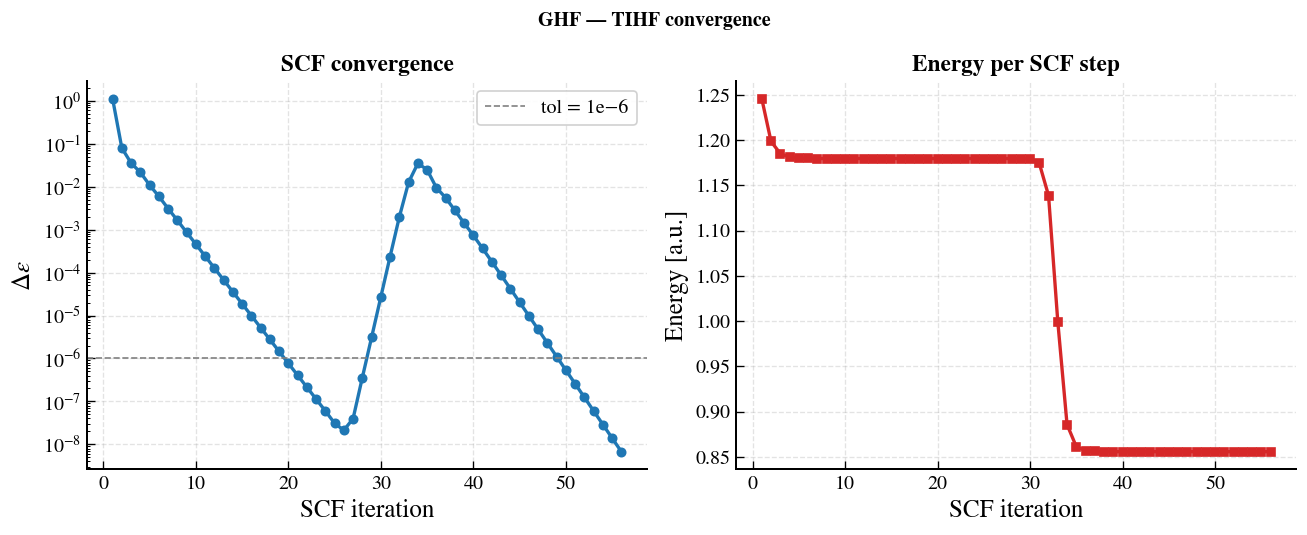

In [5]:
# SCF convergence diagnostic
ghf.plot_convergence(delta_per_step, eps_per_step)

## §5 — GHF: One-Body Density $\rho(x)$

The ground-state one-body density gives the probability of finding an electron
at position $x$, integrated over all other degrees of freedom.

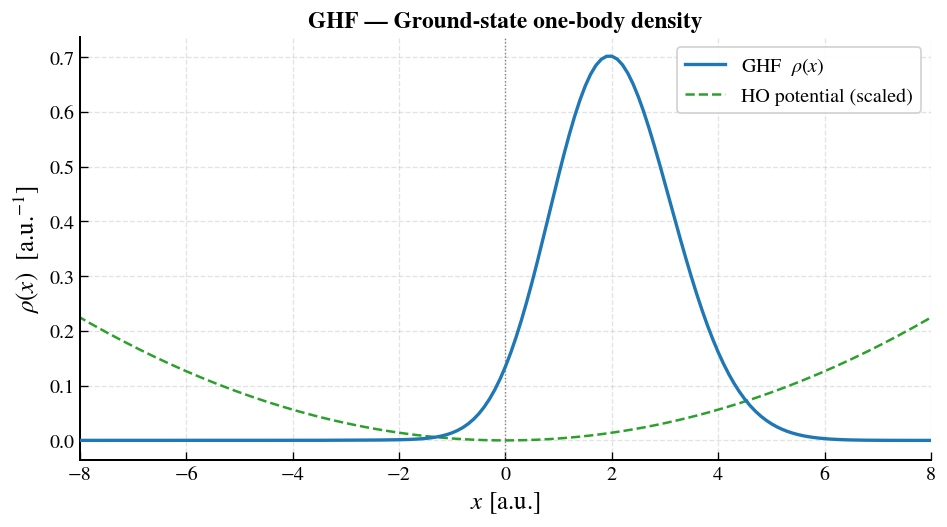

In [6]:
obd_ghf = ghf.eval_one_body_density(C0_ghf)
ghf.plot_one_body_density(obd_ghf, label='GHF  $\\rho(x)$')

## §6 — GHF: Short-Time TDHF Evolution (Laser On)

Propagate the system for one laser period $T = 2\pi/\Omega$ with the laser active.
The dipole moment and overlap with the initial state are recorded.

In [7]:
T_laser = 2 * np.pi / ghf.Omega   # one trap period

C_ghf, time_ghf, overlap_ghf, dipole_ghf, energy_ghf = ghf.solve_TDHF(
    tstart=0, dt=1e-3, t_max=T_laser, C0=C0_ghf,
    eval_overlap=True, eval_dipole=True, eval_energy=True,
    laser_ON=True)

print(f'Final time: {time_ghf[-1]:.4f} a.u.  ({time_ghf[-1]/T_laser:.2f} T)')

Final time: 25.1320 a.u.  (1.00 T)


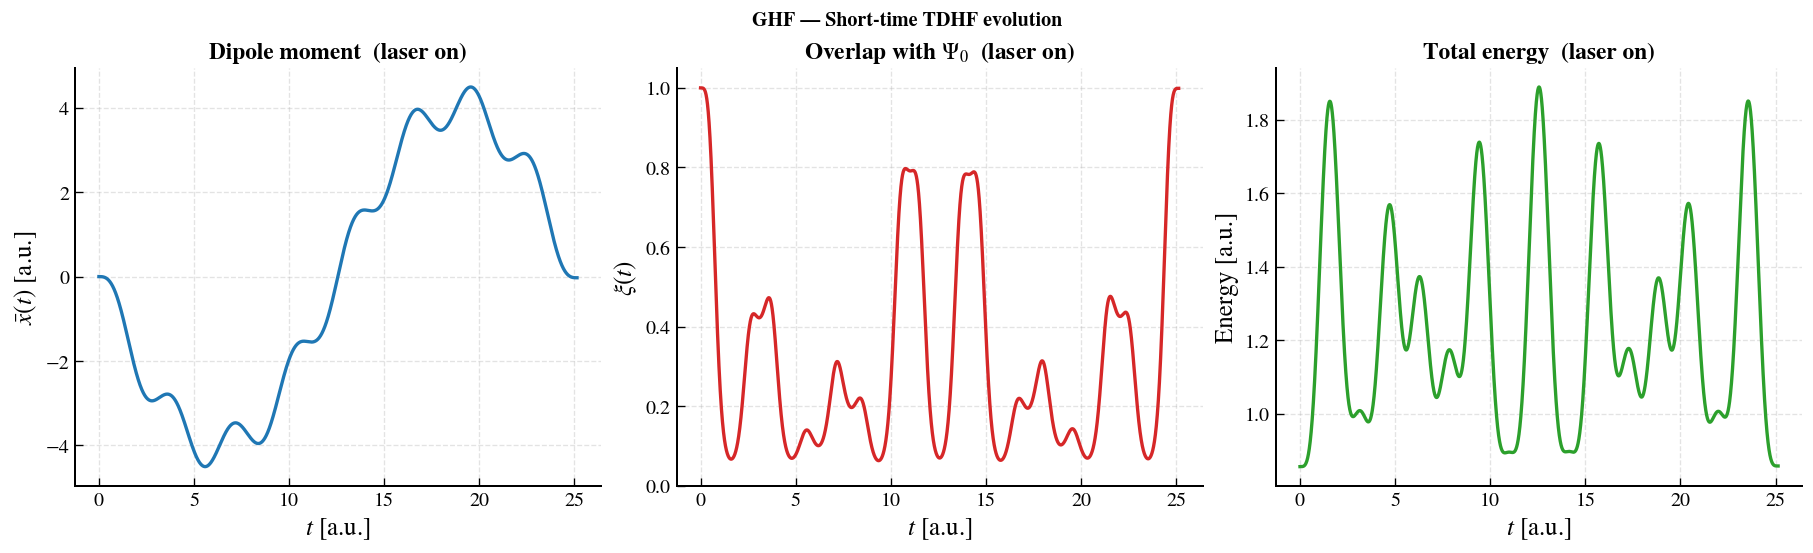

In [8]:
# Plot short-time results
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].plot(time_ghf, dipole_ghf.real, color=C0_CLR)
axes[0].set(xlabel=r'$t$ [a.u.]', ylabel=r'$\bar{x}(t)$ [a.u.]',
            title='Dipole moment  (laser on)')
axes[0].grid(True)

axes[1].plot(time_ghf, overlap_ghf.real, color=C1_CLR)
axes[1].set(xlabel=r'$t$ [a.u.]', ylabel=r'$\xi(t)$',
            title='Overlap with $\\Psi_0$  (laser on)', ylim=(0, 1.05))
axes[1].grid(True)

axes[2].plot(time_ghf, energy_ghf.real, color=C2_CLR)
axes[2].set(xlabel=r'$t$ [a.u.]', ylabel='Energy [a.u.]',
            title='Total energy  (laser on)')
axes[2].grid(True)

fig.suptitle('GHF — Short-time TDHF evolution', fontweight='bold')
plt.show()

## §7 — GHF: Fourier Analysis (Laser On → Off)

The laser is active for $t \in [0, t_{\rm off}]$, then switched off.
The FFT of the free-evolution dipole and overlap signals reveals the
natural frequencies of the correlated system.
Vertical grey dotted lines mark multiples of $\omega$ (harmonic positions).

TDHF progress: 99.9%

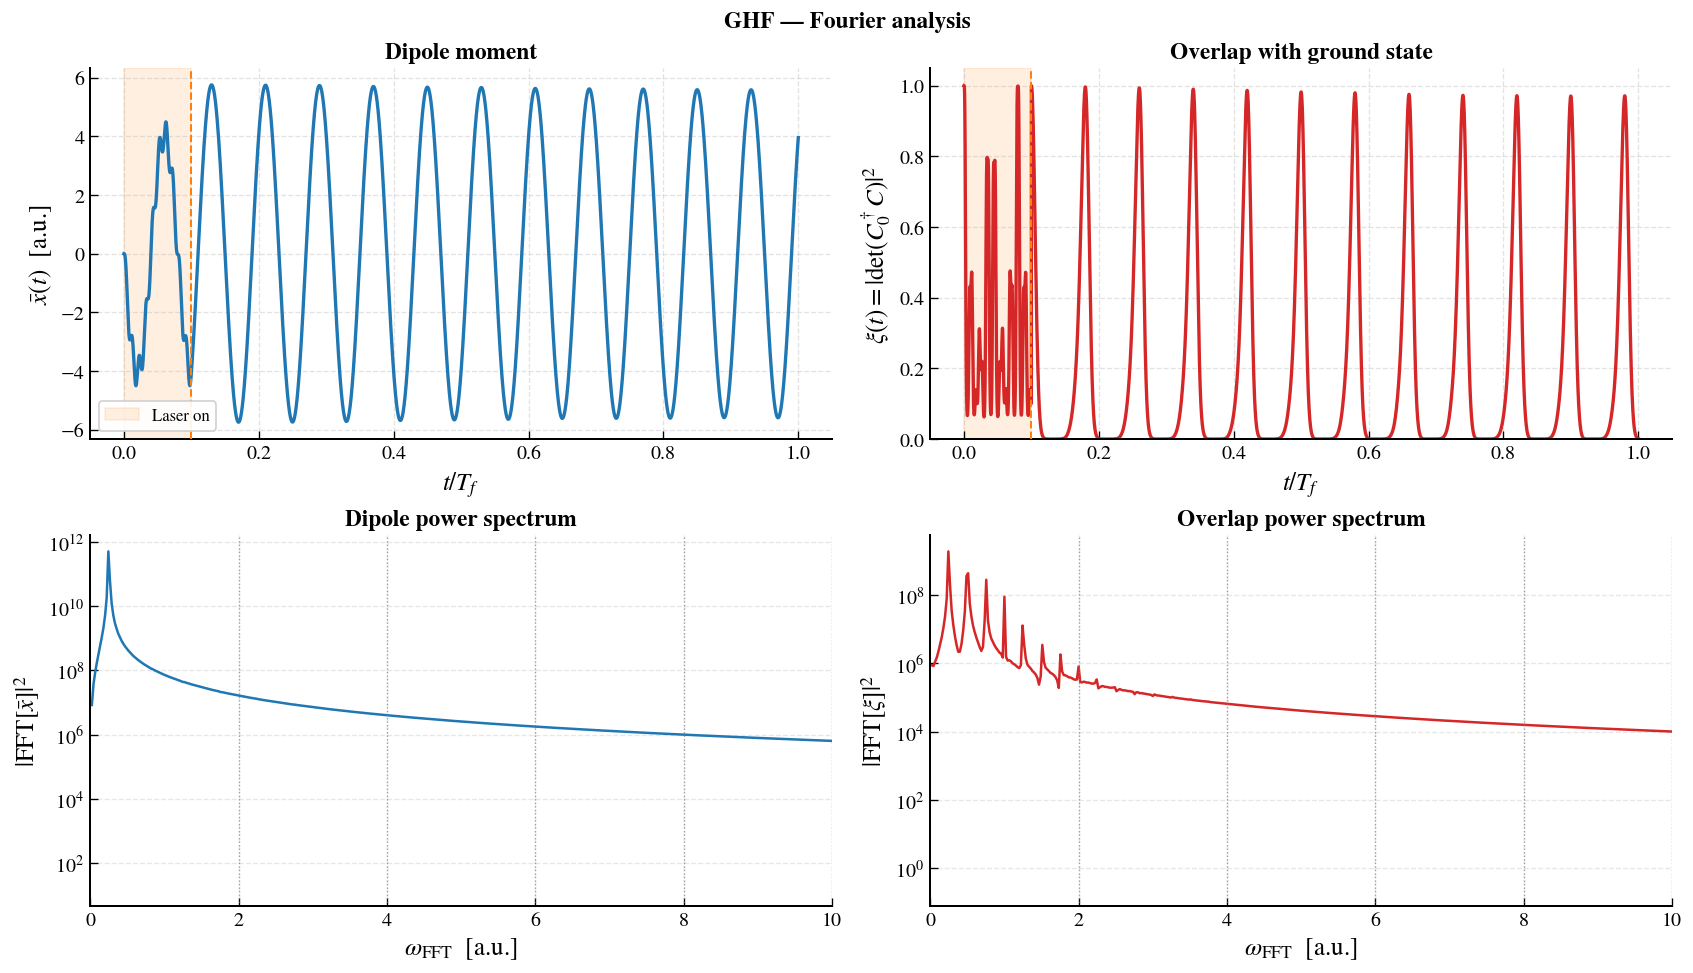

In [9]:
t_off = 10 * np.pi    # laser switch-off time
t_max_fourier = 100 * np.pi

(C2_ghf, time_fa, dipole_fa, overlap_fa,
 xFFT, xfreqFFT, overlapFFT, overlapfreqFFT, _) = ghf.fourier_analysis(
    tolerance=1e-8, max_iter=200,
    t_laser_ON=t_off, t_max=t_max_fourier, dt=1e-3,
    eval_energy=False)

ghf.plot_fourier_analysis(
    time_fa, dipole_fa, overlap_fa,
    xFFT, xfreqFFT, overlapFFT, overlapfreqFFT,
    t_laser_ON=t_off)

## §8 — RHF: Ground State (TIHF)

Repeat the SCF calculation in the **restricted** spin representation.
RHF uses spatial orbitals with double occupation; the Fock matrix
carries explicit Coulomb ($2J$) and exchange ($-K$) terms.

In [10]:
rhf = RHF(l=l, grid_length=grid_length, num_grid_points=num_grid_points,
          alpha=alpha, a=a, Omega=Omega, omega=omega, epsilon0=epsilon0,
          nparticles=nparticles)

epsilon_rhf, C0_rhf, eps_per_step_rhf, delta_per_step_rhf = rhf.solve_TIHF(
    tolerance=1e-8, max_iter=200,
    print_ON=True,
    eval_energy_per_step=True,
    eval_delta_per_step=True)

E_rhf = rhf.eval_total_energy(C0_rhf)
print(f'RHF ground-state energy: {E_rhf.real:.8f} a.u.')
print(f'Orbital energies: {epsilon_rhf[:int(nparticles/2)]}')

Converged after 27 iterations  (ΔE = 8.81e-09)
RHF ground-state energy: 1.17957129 a.u.
Orbital energies: [0.98691029]


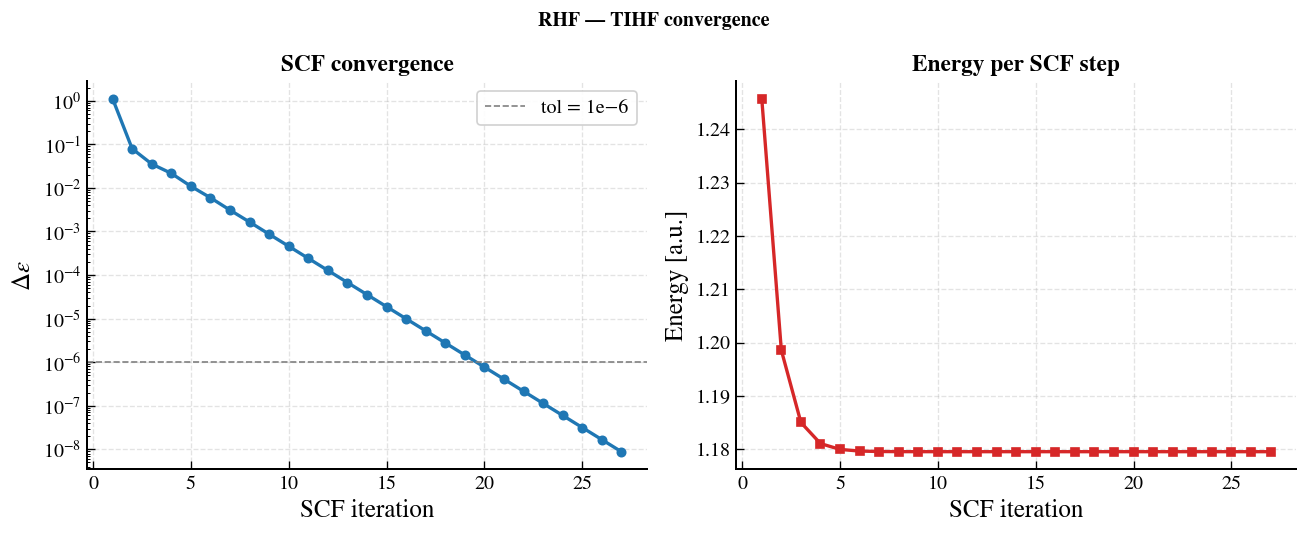

In [11]:
rhf.plot_convergence(delta_per_step_rhf, eps_per_step_rhf)

## §9 — RHF: One-Body Density

The RHF one-body density carries a factor of 2 (spin degeneracy).
Overlaying GHF and RHF densities on the same axes lets us compare the two
spin representations.

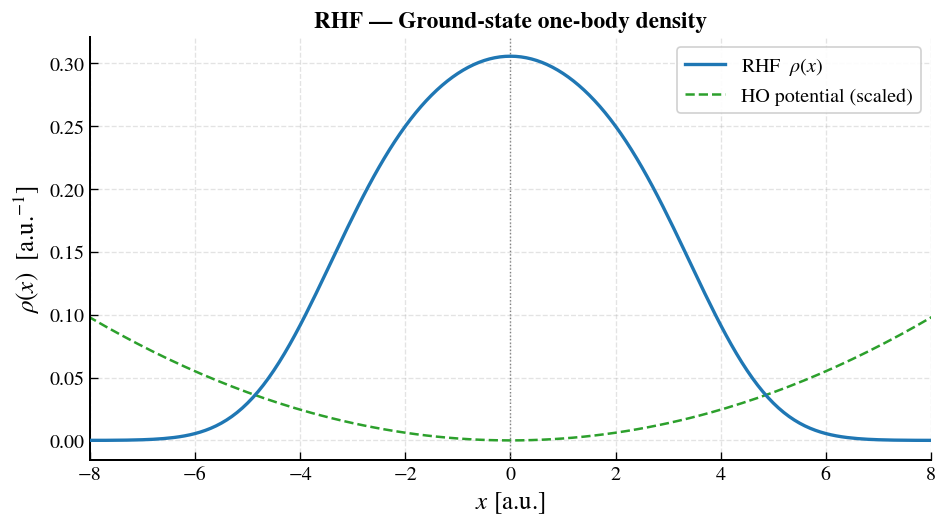

In [12]:
obd_rhf = rhf.eval_one_body_density(C0_rhf)

# Individual RHF plot
rhf.plot_one_body_density(obd_rhf, label='RHF  $\\rho(x)$')

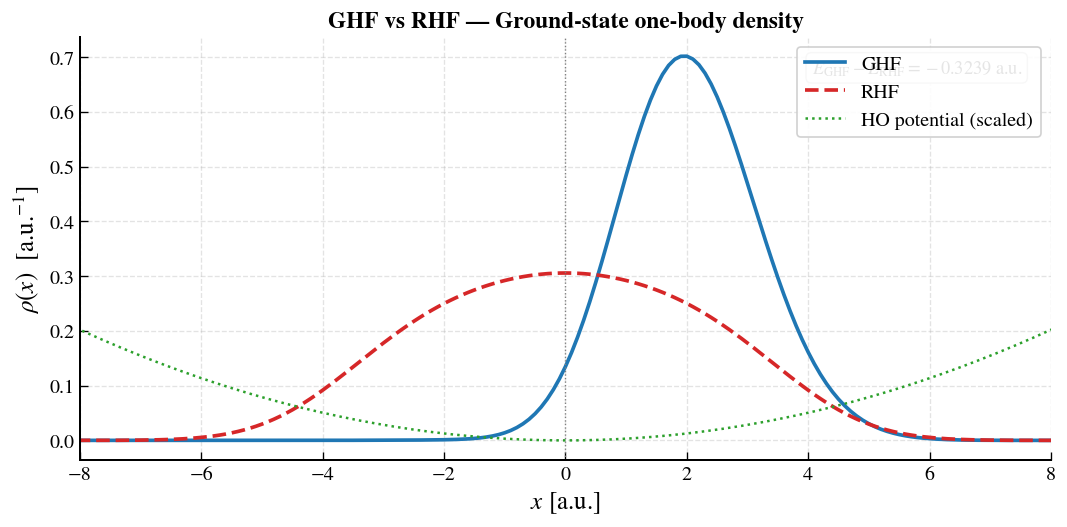

In [13]:
# ── Side-by-side GHF vs RHF comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(ghf.system.grid, obd_ghf.real, color=C0_CLR, label='GHF', lw=2.2)
ax.plot(rhf.system.grid, obd_rhf.real, color=C1_CLR, label='RHF',
        ls='--', lw=2.2)

# Scaled HO potential for reference
x = ghf.system.grid
pot = ghf.potential(x)
scale = obd_ghf.real.max() * 0.45 / pot.max()
ax.plot(x, pot * scale, color=C2_CLR, ls=':', lw=1.5,
        label=r'HO potential (scaled)')

ax.set(xlabel=r'$x$ [a.u.]',
       ylabel=r'$\rho(x)$  [a.u.$^{-1}$]',
       title='GHF vs RHF — Ground-state one-body density',
       xlim=(-8, 8))
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.legend()
ax.grid(True)

E_diff = (E_ghf - E_rhf).real
ax.annotate(f'$E_{{\\rm GHF}} - E_{{\\rm RHF}} = {E_diff:.4f}$ a.u.',
            xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', lw=0.8))

plt.tight_layout()
plt.show()